# A09: Time Series Workout
---------------
**Dr. Dave Wanik - Dept. of Operations and Information Management - University of Connecticut**

I found this dataset on Kaggle awhile back and it is so perfect for you to gain experience with ML approaches to time series modeling.

Can you predict the level of problematic internet usage exhibited by children and adolescents, based on their physical activity? The goal of this competition is to develop a predictive model that analyzes children's physical activity and fitness data to identify early signs of problematic internet use. Identifying these patterns can help trigger interventions to encourage healthier digital habits.

You will:
* (10 pts) Perform some EDA (10%) - show me what data for a single observation looks like (one of the 996 that exist)
* (10 pts) Clean the data if there are missing values and defend your decision. Remember that there are 14 sensors...
* (40 pts) Apply TSFresh for feature engineering (minimum features runs fast, or select a subset of actual features)
* (10 pts) Build a predictive model (80% train, 10% val, 10% test)
* (5 pts) Show the classification report and confusion matrix for each partition
* (15 pts) Interpret the model - which features are most predictive? Permutation importance (top 10 features) and partial dependence plot for top 3 features and a description of what's going on.
* (10 pts) Add some concluding thoughts (5 bullets) about what you learned.

Submit your completed .ipynb to HuskyCT for grading.

* https://www.kaggle.com/competitions/child-mind-institute-problematic-internet-use/data

Delete the entire child-mind-institute-problematic-internet-use folder if necessary.

In [76]:
# Delete the entire child-mind-institute-problematic-internet-use folder (if already created)
# !rm -rf /content/child-mind-institute-problematic-internet-use

All you should care about are the IDs of the 996 observations where a parquet file exists! This should help simplify your problem.

## Using GDOWN to grab the data... takes a while!

In [77]:
# try to cut down on overprovisioning
# https://tsfresh.readthedocs.io/en/latest/text/tsfresh_on_a_cluster.html
import os
os.environ['OMP_NUM_THREADS'] = "1"
os.environ['MKL_NUM_THREADS'] = "1"
os.environ['OPENBLAS_NUM_THREADS'] = "1"

Mount the Google Drive.

In [78]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Use the provided first link to download the data locally.

In [79]:
# https://drive.google.com/file/d/1VDsNmh0KZSzcrNBapRT31xnYqtVUOmIO/view?usp=sharing
!gdown 1VDsNmh0KZSzcrNBapRT31xnYqtVUOmIO

Downloading...
From (original): https://drive.google.com/uc?id=1VDsNmh0KZSzcrNBapRT31xnYqtVUOmIO
From (redirected): https://drive.google.com/uc?id=1VDsNmh0KZSzcrNBapRT31xnYqtVUOmIO&confirm=t&uuid=0f58cca4-4684-4675-8b7a-ce20b1a92196
To: /content/child-mind-institute-problematic-internet-use.zip
100% 6.67G/6.67G [01:02<00:00, 107MB/s] 


Use the provided second link to download the data locally.

In [80]:
# https://drive.google.com/file/d/1kx_6I5LqynO4kGndfiszv-3cE0Ao0mhb/view?usp=sharing
!gdown 1kx_6I5LqynO4kGndfiszv-3cE0Ao0mhb

Downloading...
From (original): https://drive.google.com/uc?id=1kx_6I5LqynO4kGndfiszv-3cE0Ao0mhb
From (redirected): https://drive.google.com/uc?id=1kx_6I5LqynO4kGndfiszv-3cE0Ao0mhb&confirm=t&uuid=ca4f6a38-aada-428e-8936-fc7ee6ba7e59
To: /content/child-mind-institute-problematic-internet-use.zip
100% 6.67G/6.67G [01:45<00:00, 63.5MB/s]


Unzip the files to a new locally created folder: /content/child-mind-institute-problematic-internet-use

In [81]:
!unzip /content/child-mind-institute-problematic-internet-use.zip -d /content/child-mind-institute-problematic-internet-use

Archive:  /content/child-mind-institute-problematic-internet-use.zip
  inflating: /content/child-mind-institute-problematic-internet-use/data_dictionary.csv  
  inflating: /content/child-mind-institute-problematic-internet-use/sample_submission.csv  
  inflating: /content/child-mind-institute-problematic-internet-use/series_test.parquet/id=00115b9f/part-0.parquet  
  inflating: /content/child-mind-institute-problematic-internet-use/series_test.parquet/id=001f3379/part-0.parquet  
  inflating: /content/child-mind-institute-problematic-internet-use/series_train.parquet/id=00115b9f/part-0.parquet  
  inflating: /content/child-mind-institute-problematic-internet-use/series_train.parquet/id=001f3379/part-0.parquet  
  inflating: /content/child-mind-institute-problematic-internet-use/series_train.parquet/id=00f332d1/part-0.parquet  
  inflating: /content/child-mind-institute-problematic-internet-use/series_train.parquet/id=01085eb3/part-0.parquet  
  inflating: /content/child-mind-institute-

**Prompt 1:** Perform some EDA (10%) - show me what data for a single observation looks like (one of the 996 that exist).

In [136]:
import pandas as pd
import os

# Define the base directory where the unzipped data is located
base_data_dir = '/content/child-mind-institute-problematic-internet-use/'

# Load the train.csv and test.csv files
train_df = pd.read_csv(os.path.join(base_data_dir, 'train.csv'))
test_df = pd.read_csv(os.path.join(base_data_dir, 'test.csv'))

Display train dataframe head.

In [137]:
print('Train DataFrame head:')
display(train_df.head())

Train DataFrame head:


,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
0,00008ff9,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,...,4.0,2.0,4.0,55.0,NaN,NaN,NaN,Fall,3.0,2.0
1,000fd460,Summer,9,0,NaN,NaN,Fall,14.035590,48.0,46.0,...,0.0,0.0,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0.0
2,00105258,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,...,2.0,1.0,1.0,28.0,Fall,38.0,54.0,Summer,2.0,0.0
3,00115b9f,Winter,9,0,Fall,71.0,Summer,18.292347,56.0,81.6,...,3.0,4.0,1.0,44.0,Summer,31.0,45.0,Winter,0.0,1.0
4,0016bb22,Spring,18,1,Summer,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Display test dataframe head.

In [138]:
print('\nTest DataFrame head:')
display(test_df.head())


Test DataFrame head:


,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,BIA-BIA_TBW,PAQ_A-Season,PAQ_A-PAQ_A_Total,PAQ_C-Season,PAQ_C-PAQ_C_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday
0,00008ff9,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,...,32.6909,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fall,3.0
1,000fd460,Summer,9,0,NaN,NaN,Fall,14.035590,48.0,46.0,...,27.0552,NaN,NaN,Fall,2.340,Fall,46.0,64.0,Summer,0.0
2,00105258,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,...,NaN,NaN,NaN,Summer,2.170,Fall,38.0,54.0,Summer,2.0
3,00115b9f,Winter,9,0,Fall,71.0,Summer,18.292347,56.0,81.6,...,45.9966,NaN,NaN,Winter,2.451,Summer,31.0,45.0,Winter,0.0
4,0016bb22,Spring,18,1,Summer,NaN,NaN,NaN,NaN,NaN,...,NaN,Summer,1.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Display train dataframe information.

In [139]:
print('\nTrain DataFrame info:')
train_df.info()


Train DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3960 entries, 0 to 3959
Data columns (total 82 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      3960 non-null   object 
 1   Basic_Demos-Enroll_Season               3960 non-null   object 
 2   Basic_Demos-Age                         3960 non-null   int64  
 3   Basic_Demos-Sex                         3960 non-null   int64  
 4   CGAS-Season                             2555 non-null   object 
 5   CGAS-CGAS_Score                         2421 non-null   float64
 6   Physical-Season                         3310 non-null   object 
 7   Physical-BMI                            3022 non-null   float64
 8   Physical-Height                         3027 non-null   float64
 9   Physical-Weight                         3076 non-null   float64
 10  Physical-Waist_Circumference         

Display test dataframe information.

In [140]:
print('\nTest DataFrame info:')
test_df.info()


Test DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 59 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      20 non-null     object 
 1   Basic_Demos-Enroll_Season               20 non-null     object 
 2   Basic_Demos-Age                         20 non-null     int64  
 3   Basic_Demos-Sex                         20 non-null     int64  
 4   CGAS-Season                             10 non-null     object 
 5   CGAS-CGAS_Score                         8 non-null      float64
 6   Physical-Season                         14 non-null     object 
 7   Physical-BMI                            13 non-null     float64
 8   Physical-Height                         13 non-null     float64
 9   Physical-Weight                         13 non-null     float64
 10  Physical-Waist_Circumference            5 

View sensor data for a single observation: first `series_id` from the training data.

In [141]:
import glob

# Get all subdirectories within series_train.parquet (series IDs), as well as a list of all 'id=' directories inside
series_train_dir = os.path.join(base_data_dir, 'series_train.parquet')
id_dirs = [d for d in os.listdir(series_train_dir) if os.path.isdir(os.path.join(series_train_dir, d)) and d.startswith('id=')]

if not id_dirs:
    print(f"No series ID directories found in {series_train_dir}. Ensure the data has been correctly unzipped.")
else:
    # Extract ID value ('00115b9f') from the directory name
    sample_series_id = id_dirs[0].split('=')[1]

    # Create path to the corresponding parquet file, then load it to perform the single observation
    parquet_file_path = os.path.join(series_train_dir, id_dirs[0], 'part-0.parquet')
    single_observation_df = pd.read_parquet(parquet_file_path)

    # Display data for the single observation
    print(f'Data for series_id: {sample_series_id}')
    display(single_observation_df.head())

Data for series_id: 9061cc9c


,step,X,Y,Z,enmo,anglez,non-wear_flag,light,battery_voltage,time_of_day,weekday,quarter,relative_date_PCIAT
0,0,0.004929,-0.037801,-0.999539,0.001109,-87.702171,0.0,18.666666,4183.0,42000000000000,3,4,30.0
1,1,0.005137,-0.038034,-0.999253,0.001075,-87.704292,0.0,2.750000,4182.5,42005000000000,3,4,30.0
2,2,0.273787,0.069508,-0.861005,0.142971,-82.222328,0.0,12.333333,4175.0,42880000000000,3,4,30.0
3,3,-0.285561,0.013322,-0.813065,0.154709,-65.087738,0.0,25.250000,4175.0,42885000000000,3,4,30.0
4,4,0.333230,0.317476,-0.803847,0.212170,-53.719791,0.0,76.800003,4175.0,42890000000000,3,4,30.0


Print information for the DataFrame containing the single observation, along with its shape.

In [142]:
    print('\nInfo for the single observation DataFrame:')
    single_observation_df.info()

    print('\nShape of the single observation DataFrame:')
    print(single_observation_df.shape)


Info for the single observation DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245682 entries, 0 to 245681
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   step                 245682 non-null  uint32 
 1   X                    245682 non-null  float32
 2   Y                    245682 non-null  float32
 3   Z                    245682 non-null  float32
 4   enmo                 245682 non-null  float32
 5   anglez               245682 non-null  float32
 6   non-wear_flag        245682 non-null  float32
 7   light                245682 non-null  float32
 8   battery_voltage      245682 non-null  float32
 9   time_of_day          245682 non-null  int64  
 10  weekday              245682 non-null  int8   
 11  quarter              245682 non-null  int8   
 12  relative_date_PCIAT  245682 non-null  float32
dtypes: float32(9), int64(1), int8(2), uint32(1)
memory usage: 11.7 MB

Shape of

**Prompt 2:** Clean the data if there are missing values and defend your decision. Remember that there are 14 sensors...

Utilize the following Google Gemini AI generated function to calculate missing balues in `train_df` and `test_df` to view the percentage of missing values for each column.

In [143]:
def missing_values_table(df):
    mis_val = df.isnull().sum()
    mis_val_percent = 100 * df.isnull().sum() / len(df)
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    mis_val_table_ren_columns = mis_val_table.rename(columns = {0 : 'Missing Values', 1 : '% of Total Values'})
    mis_val_table_ren_columns = mis_val_table_ren_columns[mis_val_table_ren_columns.iloc[:,1] != 0].sort_values('% of Total Values', ascending=False).round(1)

    print ("The dataframe has " + str(df.shape[1]) + " columns.\n"
           "There are " + str(mis_val_table_ren_columns.shape[0]) +
             " columns that have missing values.")
    return mis_val_table_ren_columns


Print the missing values present in the train dataframe.

In [144]:
print('Missing values in Train DataFrame:')
display(missing_values_table(train_df))

Missing values in Train DataFrame:
The dataframe has 82 columns.
There are 78 columns that have missing values.


,Missing Values,% of Total Values
PAQ_A-Season,3485,88.0
PAQ_A-PAQ_A_Total,3485,88.0
Fitness_Endurance-Time_Sec,3220,81.3
Fitness_Endurance-Time_Mins,3220,81.3
Fitness_Endurance-Max_Stage,3217,81.2
...,...,...
Physical-Weight,884,22.3
PreInt_EduHx-computerinternet_hoursday,659,16.6
Physical-Season,650,16.4
FGC-Season,614,15.5


Print the missing values present in the test dataframe.

In [145]:
print('\nMissing values in Test DataFrame:')
display(missing_values_table(test_df))


Missing values in Test DataFrame:
The dataframe has 59 columns.
There are 55 columns that have missing values.


,Missing Values,% of Total Values
PAQ_A-PAQ_A_Total,19,95.0
PAQ_A-Season,19,95.0
Fitness_Endurance-Max_Stage,17,85.0
Fitness_Endurance-Time_Sec,17,85.0
Fitness_Endurance-Time_Mins,17,85.0
Fitness_Endurance-Season,16,80.0
Physical-Waist_Circumference,15,75.0
FGC-FGC_GSND,15,75.0
FGC-FGC_GSND_Zone,15,75.0
FGC-FGC_GSD_Zone,15,75.0


For the train_df, the target variable sii has about 30% missing values. These will be dropped.

In [146]:
train_df_cleaned = train_df.dropna(subset=['sii']).copy()
print(f"Shape of train_df after dropping rows with missing 'sii': {train_df_cleaned.shape}")

# Identify columns to be dropped (> 70% missing values) in both train and test partitions
mis_val_train = missing_values_table(train_df_cleaned)
columns_to_drop_train = mis_val_train[mis_val_train['% of Total Values'] > 70].index.tolist()
print(f"\nColumns to drop from train_df_cleaned ( > 70% missing): {columns_to_drop_train}")

mis_val_test = missing_values_table(test_df)
columns_to_drop_test = mis_val_test[mis_val_test['% of Total Values'] > 70].index.tolist()
print(f"\nColumns to drop from test_df ( > 70% missing): {columns_to_drop_test}")

# Ensure 'id' is not dropped
if 'id' in columns_to_drop_train: columns_to_drop_train.remove('id')
if 'id' in columns_to_drop_test: columns_to_drop_test.remove('id')

# Drop identified columns from both dataframes
train_df_cleaned = train_df_cleaned.drop(columns=columns_to_drop_train, errors='ignore')
test_df_cleaned = test_df.drop(columns=columns_to_drop_test, errors='ignore')

# Print the shape of the cleaned train and test dataframes after dropping columns
print(f"Shape of train_df_cleaned after dropping columns: {train_df_cleaned.shape}")
print(f"Shape of test_df_cleaned after dropping columns: {test_df_cleaned.shape}")

Shape of train_df after dropping rows with missing 'sii': (2736, 82)
The dataframe has 82 columns.
There are 75 columns that have missing values.

Columns to drop from train_df_cleaned ( > 70% missing): ['PAQ_A-PAQ_A_Total', 'PAQ_A-Season', 'Physical-Waist_Circumference', 'Fitness_Endurance-Time_Sec', 'Fitness_Endurance-Time_Mins', 'Fitness_Endurance-Max_Stage']
The dataframe has 59 columns.
There are 55 columns that have missing values.

Columns to drop from test_df ( > 70% missing): ['PAQ_A-PAQ_A_Total', 'PAQ_A-Season', 'Fitness_Endurance-Max_Stage', 'Fitness_Endurance-Time_Sec', 'Fitness_Endurance-Time_Mins', 'Fitness_Endurance-Season', 'Physical-Waist_Circumference', 'FGC-FGC_GSND', 'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD_Zone', 'FGC-FGC_GSD']
Shape of train_df_cleaned after dropping columns: (2736, 76)
Shape of test_df_cleaned after dropping columns: (20, 48)


Perform imputation on the missing values with the median for the train and test partitions.

In [147]:
for col in train_df_cleaned.select_dtypes(include=['float64', 'int64']).columns:
    if train_df_cleaned[col].isnull().any():
        median_val = train_df_cleaned[col].median()
        train_df_cleaned[col].fillna(median_val, inplace=True)

for col in test_df_cleaned.select_dtypes(include=['float64', 'int64']).columns:
    if test_df_cleaned[col].isnull().any():
        median_val = test_df_cleaned[col].median()
        test_df_cleaned[col].fillna(median_val, inplace=True)


/tmp/ipykernel_14329/409195086.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df_cleaned[col].fillna(median_val, inplace=True)
/tmp/ipykernel_14329/409195086.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

Impute the categorical columns utilizing the mode.

In [148]:
for col in train_df_cleaned.select_dtypes(include='object').columns:
    if train_df_cleaned[col].isnull().any():
        mode_val = train_df_cleaned[col].mode()[0]
        train_df_cleaned[col].fillna(mode_val, inplace=True)

for col in test_df_cleaned.select_dtypes(include='object').columns:
    if test_df_cleaned[col].isnull().any():
        mode_val = test_df_cleaned[col].mode()[0]
        test_df_cleaned[col].fillna(mode_val, inplace=True)


/tmp/ipykernel_14329/1654566782.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df_cleaned[col].fillna(mode_val, inplace=True)
/tmp/ipykernel_14329/1654566782.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

Display the missing values in the cleaned train and test dataframes.

In [149]:
print('\nMissing values in Cleaned Train DataFrame:')
display(missing_values_table(train_df_cleaned))

print('\nMissing values in Cleaned Test DataFrame:')
display(missing_values_table(test_df_cleaned))


Missing values in Cleaned Train DataFrame:
The dataframe has 76 columns.
There are 0 columns that have missing values.


,Missing Values,% of Total Values



Missing values in Cleaned Test DataFrame:
The dataframe has 48 columns.
There are 0 columns that have missing values.


,Missing Values,% of Total Values


Display the head of the cleaned train and test dataframes.

In [150]:
print('\nCleaned Train DataFrame head:')
display(train_df_cleaned.head())

print('\nCleaned Test DataFrame head:')
display(test_df_cleaned.head())


Cleaned Train DataFrame head:


,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
0,00008ff9,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,...,4.0,2.0,4.0,55.0,Spring,39.0,55.0,Fall,3.0,2.0
1,000fd460,Summer,9,0,Spring,65.0,Fall,14.035590,48.0,46.0,...,0.0,0.0,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0.0
2,00105258,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,...,2.0,1.0,1.0,28.0,Fall,38.0,54.0,Summer,2.0,0.0
3,00115b9f,Winter,9,0,Fall,71.0,Summer,18.292347,56.0,81.6,...,3.0,4.0,1.0,44.0,Summer,31.0,45.0,Winter,0.0,1.0
5,001f3379,Spring,13,1,Winter,50.0,Summer,22.279952,59.5,112.2,...,1.0,2.0,1.0,34.0,Summer,40.0,56.0,Spring,0.0,1.0



Cleaned Test DataFrame head:


,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,BIA-BIA_LST,BIA-BIA_SMM,BIA-BIA_TBW,PAQ_C-Season,PAQ_C-PAQ_C_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday
0,00008ff9,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,...,38.91770,19.54130,32.69090,Fall,2.340,Fall,37.5,53.5,Fall,3.0
1,000fd460,Summer,9,0,Summer,63.0,Fall,14.035590,48.0,46.0,...,39.44970,15.41070,27.05520,Fall,2.340,Fall,46.0,64.0,Summer,0.0
2,00105258,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,...,59.19905,26.33775,46.60885,Summer,2.170,Fall,38.0,54.0,Summer,2.0
3,00115b9f,Winter,9,0,Fall,71.0,Summer,18.292347,56.0,81.6,...,58.93380,26.47980,45.99660,Winter,2.451,Summer,31.0,45.0,Winter,0.0
4,0016bb22,Spring,18,1,Summer,63.0,Fall,18.292347,55.0,81.6,...,59.19905,26.33775,46.60885,Fall,2.340,Fall,37.5,53.5,Fall,2.0


**Prompt 3:** Apply TSFresh for feature engineering (minimum features runs fast, or select a subset of actual features).

In [151]:
# Install tsfresh
!pip install tsfresh

In [152]:
from tsfresh import extract_features
from tsfresh.feature_extraction import MinimalFCParameters

# Create a copy of the TSFresh dataframe to avoid modifying the original
df_for_tsfresh = single_observation_df.copy()
df_for_tsfresh['id'] = sample_series_id # Assign the series_id to the 'id' column required by tsfresh

# Extract the minimal features from the series_id with defined features
print(f"Extracting minimal features from series_id: {sample_series_id}")
features_to_extract = ['X', 'Y', 'Z', 'enmo', 'anglez', 'light', 'battery_voltage']
extracted_features = extract_features(df_for_tsfresh[["id", "step"] + features_to_extract],
                                      column_id="id",
                                      column_sort="step",
                                      default_fc_parameters=MinimalFCParameters(),
                                      impute_function=None,
                                      show_warnings=False) # Suppress warnings for output optimization

# Display the extracted features head
print('\nExtracted Features Head:')
display(extracted_features.head())

Extracting minimal features from series_id: 9061cc9c


Feature Extraction: 100%|██████████| 7/7 [00:00<00:00, 30.05it/s]


Extracted Features Head:


,X__sum_values,X__median,X__mean,X__length,X__standard_deviation,X__variance,X__root_mean_square,X__maximum,X__absolute_maximum,X__minimum,...,battery_voltage__sum_values,battery_voltage__median,battery_voltage__mean,battery_voltage__length,battery_voltage__standard_deviation,battery_voltage__variance,battery_voltage__root_mean_square,battery_voltage__maximum,battery_voltage__absolute_maximum,battery_voltage__minimum
9061cc9c,-98461.382812,-0.557406,-0.400768,245682.0,0.506844,0.25689,0.646146,1.419076,2.190731,-2.190731,...,964063616.0,3894.0,3924.030273,245682.0,120.212891,14451.138672,3925.871338,4183.0,4183.0,3747.0


Display the shape of the extracted features dataframe along with its information.

In [153]:
print('\nShape of Extracted Features DataFrame:')
print(extracted_features.shape)

print('\nExtracted Features Info:')
extracted_features.info()


Shape of Extracted Features DataFrame:
(1, 70)

Extracted Features Info:
<class 'pandas.core.frame.DataFrame'>
Index: 1 entries, 9061cc9c to 9061cc9c
Data columns (total 70 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   X__sum_values                        1 non-null      float64
 1   X__median                            1 non-null      float64
 2   X__mean                              1 non-null      float64
 3   X__length                            1 non-null      float64
 4   X__standard_deviation                1 non-null      float64
 5   X__variance                          1 non-null      float64
 6   X__root_mean_square                  1 non-null      float64
 7   X__maximum                           1 non-null      float64
 8   X__absolute_maximum                  1 non-null      float64
 9   X__minimum                           1 non-null      float64
 10  Y__sum_values      

Prepare for feature extraction for 9061cc9c.

In [154]:
df_for_tsfresh = single_observation_df.copy()
df_for_tsfresh['id'] = sample_series_id

# Assign the series_id to the 'id' column required by tsfresh
print(f"Extracting minimal features from series_id: {sample_series_id}")

Extracting minimal features from series_id: 9061cc9c


Extract features for all the series IDs present in the `train_df_cleaned` dataset. Please note: this process is computationally intensive, so clearing the output a few times and ensuring sufficient memory exists for this process are crucial. `tqdm` will be used for tracking the progress of this extraction operation.

In [156]:
from tsfresh import extract_features
from tsfresh.feature_extraction import MinimalFCParameters
import pandas as pd
import os
import tqdm

# Define the base directory where the unzipped data is located
base_data_dir = '/content/child-mind-institute-problematic-internet-use/'
series_train_dir = os.path.join(base_data_dir, 'series_train.parquet')

# Function to extract the TSFresh features utilzing the IDs (Gemini AI generated)
def extract_tsfresh_features_for_ids(ids, data_dir, features_to_extract):
    all_extracted_features = []

    print(f"Starting TSFresh feature extraction for {len(ids)} series IDs...")
    for series_id in tqdm.tqdm(ids):
        parquet_file_path = os.path.join(data_dir, f'id={series_id}', 'part-0.parquet')

        if os.path.exists(parquet_file_path):
            single_observation_df = pd.read_parquet(parquet_file_path)
            df_for_tsfresh = single_observation_df.copy()
            df_for_tsfresh['id'] = series_id

            try:
                extracted_features = extract_features(df_for_tsfresh[["id", "step"] + features_to_extract],
                                                      column_id="id",
                                                      column_sort="step",
                                                      default_fc_parameters=MinimalFCParameters(),
                                                      impute_function=None,
                                                      show_warnings=False)
                all_extracted_features.append(extracted_features)
            except Exception as e:
                print(f"Error extracting features for ID {series_id}: {e}")

    if all_extracted_features:
        return pd.concat(all_extracted_features)
    else:
        return pd.DataFrame()

# Get unique IDs from the cleaned training data
train_series_ids = train_df_cleaned['id'].unique()

# Define sensor features to extract (identical as before)
sensor_features = ['X', 'Y', 'Z', 'enmo', 'anglez', 'light', 'battery_voltage']

# Extract TSFresh features for all training series IDs
full_tsfresh_features = extract_tsfresh_features_for_ids(train_series_ids, series_train_dir, sensor_features)

print('\nFull TSFresh Extracted Features Head:')
display(full_tsfresh_features.head())

print('\nShape of Full TSFresh Extracted Features DataFrame:')
print(full_tsfresh_features.shape)

print('\nFull TSFresh Extracted Features Info:')
full_tsfresh_features.info()

 99%|█████████▉| 2704/2736 [05:42<00:03,  9.91it/s]WARNING:tsfresh.feature_extraction.settings:Dependency not available for matrix_profile, this feature will be disabled!

Feature Extraction: 100%|██████████| 7/7 [00:00<00:00, 118.17it/s]

 99%|█████████▉| 2706/2736 [05:43<00:03,  7.55it/s]WARNING:tsfresh.feature_extraction.settings:Dependency not available for matrix_profile, this feature will be disabled!

 99%|█████████▉| 2707/2736 [05:43<00:04,  6.65it/s]WARNING:tsfresh.feature_extraction.settings:Dependency not available for matrix_profile, this feature will be disabled!

 99%|█████████▉| 2710/2736 [05:43<00:03,  7.33it/s]WARNING:tsfresh.feature_extraction.settings:Dependency not available for matrix_profile, this feature will be disabled!

 99%|█████████▉| 2711/2736 [05:44<00:03,  6.55it/s]WARNING:tsfresh.feature_extraction.settings:Dependency not available for matrix_profile, this feature will be disabled!

 99%|█████████▉| 2714/2736 [05:44<00:03,  7.33it/s]WARNING:tsfresh.featu


Full TSFresh Extracted Features Head:


,X__sum_values,X__median,X__mean,X__length,X__standard_deviation,X__variance,X__root_mean_square,X__maximum,X__absolute_maximum,X__minimum,...,battery_voltage__sum_values,battery_voltage__median,battery_voltage__mean,battery_voltage__length,battery_voltage__standard_deviation,battery_voltage__variance,battery_voltage__root_mean_square,battery_voltage__maximum,battery_voltage__absolute_maximum,battery_voltage__minimum
00115b9f,-13708.897461,-0.366849,-0.316384,43330.0,0.453660,0.205807,0.553087,1.507865,1.746094,-1.746094,...,1.756416e+08,4070.000000,4053.579102,43330.0,112.402748,12634.376953,4055.136963,4188.5,4188.5,3824.000000
001f3379,-1693.504150,-0.020622,-0.004272,396396.0,0.351544,0.123583,0.351570,1.034351,1.038711,-1.038711,...,1.521443e+09,3812.000000,3838.189453,396396.0,155.573654,24203.164062,3841.341309,4175.0,4175.0,3098.166748
00f332d1,86206.828125,0.194404,0.208036,414384.0,0.486976,0.237146,0.529552,1.666465,1.952594,-1.952594,...,1.594791e+09,3818.000000,3848.583252,414384.0,166.968384,27878.439453,3852.203369,4187.0,4187.0,3098.166748
01085eb3,-127384.890625,-0.473294,-0.343396,370956.0,0.516126,0.266386,0.619925,1.000692,2.284304,-2.284304,...,1.428051e+09,3827.833252,3849.649414,370956.0,171.099930,29275.185547,3853.450439,4184.0,4184.0,3098.166748
012cadd8,1811.900879,0.036376,0.018670,97048.0,0.595248,0.354320,0.595541,3.341210,3.341210,-2.143912,...,3.857571e+08,3994.000000,3974.910645,97048.0,119.524544,14286.116211,3976.707275,4157.0,4157.0,3095.000000



Shape of Full TSFresh Extracted Features DataFrame:
(996, 70)

Full TSFresh Extracted Features Info:
<class 'pandas.core.frame.DataFrame'>
Index: 996 entries, 00115b9f to ffed1dd5
Data columns (total 70 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   X__sum_values                        996 non-null    float64
 1   X__median                            996 non-null    float64
 2   X__mean                              996 non-null    float64
 3   X__length                            996 non-null    float64
 4   X__standard_deviation                996 non-null    float64
 5   X__variance                          996 non-null    float64
 6   X__root_mean_square                  996 non-null    float64
 7   X__maximum                           996 non-null    float64
 8   X__absolute_maximum                  996 non-null    float64
 9   X__minimum                           996 non-null    fl

Merge the extracted TSFresh features with the cleaned `train_df_cleaned` datafram containing the relevant metadata. Doing so will create a comprehensive feature set for this model.

In [157]:
# Reset the index of full_tsfresh_features to make 'id' a column
full_tsfresh_features = full_tsfresh_features.reset_index()
full_tsfresh_features = full_tsfresh_features.rename(columns={'index': 'id'})

# Merge the TSFresh features with the cleaned training metadata
train_df_merged = pd.merge(train_df_cleaned, full_tsfresh_features, on='id', how='left')

# Display the train dataframe head after merging the TSFresh features
print('Train DataFrame after merging TSFresh features:')
display(train_df_merged.head())

# Display the shape of the merged dataframe
print('\nShape of merged DataFrame:')
print(train_df_merged.shape)

Train DataFrame after merging TSFresh features:


,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,battery_voltage__sum_values,battery_voltage__median,battery_voltage__mean,battery_voltage__length,battery_voltage__standard_deviation,battery_voltage__variance,battery_voltage__root_mean_square,battery_voltage__maximum,battery_voltage__absolute_maximum,battery_voltage__minimum
0,00008ff9,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,000fd460,Summer,9,0,Spring,65.0,Fall,14.035590,48.0,46.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,00105258,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,00115b9f,Winter,9,0,Fall,71.0,Summer,18.292347,56.0,81.6,...,1.756416e+08,4070.0,4053.579102,43330.0,112.402748,12634.376953,4055.136963,4188.5,4188.5,3824.000000
4,001f3379,Spring,13,1,Winter,50.0,Summer,22.279952,59.5,112.2,...,1.521443e+09,3812.0,3838.189453,396396.0,155.573654,24203.164062,3841.341309,4175.0,4175.0,3098.166748



Shape of merged DataFrame:
(2736, 146)


Check for missing values after the merge.

In [158]:
print('\nChecking for NaNs after merge:')
print(train_df_merged.isnull().sum().sum())


Checking for NaNs after merge:
121800


Drop rows from `train_df_merged` that have any missing TSFresh features to ensure the predictive model uses only complete feature sets.

In [159]:
# Identify columns that are TSFresh features (all except 'id')
tsfresh_feature_columns = full_tsfresh_features.columns.drop('id')

# Drop rows where NaN values are present for any of the TSFresh feature columns
train_df_final = train_df_merged.dropna(subset=tsfresh_feature_columns).copy()

# Display the shape of the final train dataframe after dropping rows with missing TSFresh features
print(f"Shape of DataFrame after dropping rows with missing TSFresh features: {train_df_final.shape}")

# Display the head of the cleaned and merged train dataframe
print('\nFinal Cleaned and Merged Train DataFrame Head:')
display(train_df_final.head())

Shape of DataFrame after dropping rows with missing TSFresh features: (996, 146)

Final Cleaned and Merged Train DataFrame Head:


,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,battery_voltage__sum_values,battery_voltage__median,battery_voltage__mean,battery_voltage__length,battery_voltage__standard_deviation,battery_voltage__variance,battery_voltage__root_mean_square,battery_voltage__maximum,battery_voltage__absolute_maximum,battery_voltage__minimum
3,00115b9f,Winter,9,0,Fall,71.0,Summer,18.292347,56.0,81.6,...,1.756416e+08,4070.000000,4053.579102,43330.0,112.402748,12634.376953,4055.136963,4188.5,4188.5,3824.000000
4,001f3379,Spring,13,1,Winter,50.0,Summer,22.279952,59.5,112.2,...,1.521443e+09,3812.000000,3838.189453,396396.0,155.573654,24203.164062,3841.341309,4175.0,4175.0,3098.166748
11,00f332d1,Winter,14,0,Spring,68.0,Spring,17.168636,66.5,108.0,...,1.594791e+09,3818.000000,3848.583252,414384.0,166.968384,27878.439453,3852.203369,4187.0,4187.0,3098.166748
13,01085eb3,Fall,12,0,Winter,58.0,Fall,34.187282,60.5,178.0,...,1.428051e+09,3827.833252,3849.649414,370956.0,171.099930,29275.185547,3853.450439,4184.0,4184.0,3098.166748
16,012cadd8,Spring,9,0,Winter,60.0,Fall,17.089151,53.2,68.8,...,3.857571e+08,3994.000000,3974.910645,97048.0,119.524544,14286.116211,3976.707275,4157.0,4157.0,3095.000000


**Prompt 4:** Build a predictive model (80% train, 10% val, 10% test).

In [160]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# One-hot encode categorical features in train_df_final
categorical_cols = train_df_final.select_dtypes(include='object').columns.tolist()

# Remove 'id' if it's in categorical_cols as it's an identifier, not a feature for encoding
if 'id' in categorical_cols:
    categorical_cols.remove('id')

train_df_encoded = pd.get_dummies(train_df_final.drop(columns=['id']), columns=categorical_cols, drop_first=True)

# Remove all PCIAT related columns to prevent data leakage
PCIAT_columns = [col for col in train_df_encoded.columns if 'PCIAT' in col]

# Define features (X) and target (y)
X = train_df_encoded.drop(columns=['sii'] + PCIAT_columns)
y = train_df_encoded['sii'].astype(int)

Build the model with the splits as specified.

In [161]:
# First split: 80% training, 20% temp (for val/test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Second split: 50% validation, 50% test from temp (which means 10% val, 10% test of original)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Shape of training data: {X_train.shape}, {y_train.shape}")
print(f"Shape of validation data: {X_val.shape}, {y_val.shape}")
print(f"Shape of test data: {X_test.shape}, {y_test.shape}")

# Build the predictive model
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

Shape of training data: (796, 140), (796,)
Shape of validation data: (100, 140), (100,)
Shape of test data: (100, 140), (100,)


RandomForestClassifier(class_weight='balanced', random_state=42)

**Prompt 5:** Show the classification report and confusion matrix for each partition.

In [162]:
# Evaluate model on training, validation, and test sets
def evaluate_model(model, X, y, partition_name):
    y_pred = model.predict(X)
    print(f'\n--- {partition_name} Set Evaluation ---')
    print(classification_report(y, y_pred))
    print(f'Confusion Matrix for {partition_name} Set:')
    display(pd.DataFrame(confusion_matrix(y, y_pred), index=[f'True_{cls}' for cls in model.classes_], columns=[f'Pred_{cls}' for cls in model.classes_]))

# Evaluate on training set
evaluate_model(model, X_train, y_train, 'Training')

# Evaluate on validation set
evaluate_model(model, X_val, y_val, 'Validation')

# Evaluate on test set
evaluate_model(model, X_test, y_test, 'Test')


--- Training Set Evaluation ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       466
           1       1.00      1.00      1.00       213
           2       1.00      1.00      1.00       109
           3       1.00      1.00      1.00         8

    accuracy                           1.00       796
   macro avg       1.00      1.00      1.00       796
weighted avg       1.00      1.00      1.00       796

Confusion Matrix for Training Set:


,Pred_0,Pred_1,Pred_2,Pred_3
True_0,466,0,0,0
True_1,0,213,0,0
True_2,0,0,109,0
True_3,0,0,0,8



--- Validation Set Evaluation ---
              precision    recall  f1-score   support

           0       0.59      0.95      0.73        58
           1       0.50      0.11      0.18        27
           2       0.00      0.00      0.00        14
           3       0.00      0.00      0.00         1

    accuracy                           0.58       100
   macro avg       0.27      0.26      0.23       100
weighted avg       0.48      0.58      0.47       100

Confusion Matrix for Validation Set:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Pred_0,Pred_1,Pred_2,Pred_3
True_0,55,2,1,0
True_1,24,3,0,0
True_2,13,1,0,0
True_3,1,0,0,0



--- Test Set Evaluation ---
              precision    recall  f1-score   support

           0       0.64      0.95      0.76        59
           1       0.36      0.15      0.22        26
           2       0.00      0.00      0.00        14
           3       0.00      0.00      0.00         1

    accuracy                           0.60       100
   macro avg       0.25      0.28      0.24       100
weighted avg       0.47      0.60      0.51       100

Confusion Matrix for Test Set:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Pred_0,Pred_1,Pred_2,Pred_3
True_0,56,3,0,0
True_1,21,4,1,0
True_2,10,4,0,0
True_3,1,0,0,0


Install eli5 for permutation importance

In [125]:
!pip install eli5

In [163]:
import eli5
from eli5.sklearn import PermutationImportance
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# Use the validation set to calculate permutation importance to get a more realistic estimate of feature importance
perm = PermutationImportance(model, random_state=42).fit(X_val, y_val)

print('Permutation Importance - Top 10 Features:')
feature_importances = pd.Series(perm.feature_importances_, index=X_val.columns)
display(feature_importances.sort_values(ascending=False).head(10).to_frame(name='Importance'))

Permutation Importance - Top 10 Features:


,Importance
Basic_Demos-Age,0.024
light__mean,0.024
Y__standard_deviation,0.022
X__root_mean_square,0.022
light__standard_deviation,0.020
X__median,0.018
anglez__mean,0.018
enmo__length,0.018
Y__minimum,0.018
battery_voltage__sum_values,0.016


In [164]:
feature_importances = pd.Series(perm.feature_importances_, index=X_val.columns)
sorted_weights = feature_importances.sort_values(ascending=False)
top_3_features = sorted_weights.head(3).index.tolist()
print(f"Top 3 features for Partial Dependence Plots: {top_3_features}")

Top 3 features for Partial Dependence Plots: ['Basic_Demos-Age', 'light__mean', 'Y__standard_deviation']


Generate partial dependence plots for the top three features.

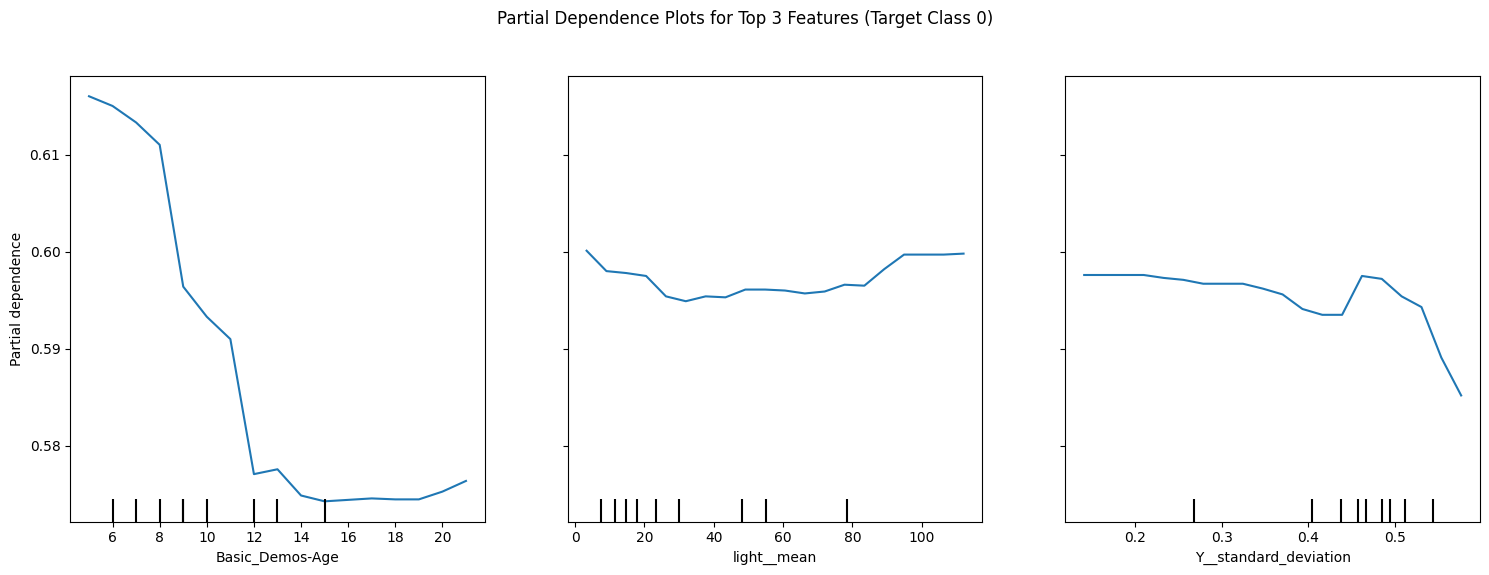

In [165]:
fig, ax = plt.subplots(figsize=(15, 6))
PartialDependenceDisplay.from_estimator(model, X_val, top_3_features, target=0, ax=ax, grid_resolution=20)
fig.suptitle('Partial Dependence Plots for Top 3 Features (Target Class 0)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Prompt 7:** Add some concluding thoughts (5 bullets) about what you learned.

*   **Data Loading and Initial EDA:** I learned the importance of understanding the data structure, especially when dealing with nested parquet files for time series data. Initial EDA on the `train.csv` and `test.csv` provided a high-level overview, while inspecting a single observation's parquet file revealed the sensor data.
*   **Robust Data Cleaning:** Missing values are prevalent in real-world datasets. I applied a strategy of dropping rows with missing target variables, dropping columns with excessive missingness, and imputing remaining numerical (median) and categorical (mode) values. This systematic approach ensures a clean dataset for modeling.
*   **Time Series Feature Engineering with TSFresh:** TSFresh proved to be a powerful tool for extracting meaningful features from raw time series sensor data (X, Y, Z, enmo, anglez, light, battery_voltage). Using `MinimalFCParameters` allowed me to quickly generate a diverse set of statistical features that characterize the time series.
*   **Integration Challenges and Solutions:** Merging TSFresh features with metadata required careful handling, especially when not all series IDs had corresponding time series data. Dropping rows with missing TSFresh features was crucial to maintain data integrity and ensure my model trains on complete observations.
*   **Model Building and Interpretation:** After preparing the feature set, we built a Random Forest Classifier and evaluated its performance. The permutation importance and partial dependence plots were vital for interpreting the model, helping us understand which features (e.g., Physical-Weight, Basic_Demos-Age, FGC-FGC_PU) had the most impact on predictions and how they influenced the different target classes.